# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch 1, 2026–2027 — Major Project**

**Objective:** Analyze agricultural data across seasons (*Kharif*, *Rabi*, *Zaid*) to uncover meaningful patterns, trends, relationships and differences in agricultural performance — covering environmental conditions, resource usage, yield, and economic outcomes — and to develop evidence-based, data-driven recommendations.

**Author:** *Sowmya R*

## Table of Contents
1. [Import Libraries](#1)
2. [Load & Understand the Dataset](#2)
3. [Data Cleaning & Preparation](#3)
4. [Univariate Analysis](#4)
5. [Seasonal Comparison — Environmental Conditions](#5)
6. [Seasonal Comparison — Resource Usage](#6)
7. [Seasonal Comparison — Yield & Production](#7)
8. [Seasonal Comparison — Economic Performance](#8)
9. [Relationships Between Variables](#9)
10. [Crop × Season & State × Season Analysis](#10)
11. [Statistical Testing](#11)
12. [Key Insights](#12)
13. [Conclusions & Recommendations](#13)


<a id='1'></a>
## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', None)

SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
SEASON_PALETTE = {'Kharif': '#2E7D32', 'Rabi': '#F9A825', 'Zaid': '#C62828'}


<a id='2'></a>
## 2. Load & Understand the Dataset

The dataset contains farm-level records describing farming practices, environmental conditions, crop production, resource usage and economic performance across three agricultural seasons.

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()


Rows: 4000, Columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


In [5]:
print("Categorical columns and their unique values:\n")
for c in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    print(f"{c} ({df[c].nunique()}): {sorted(df[c].unique())}")


Categorical columns and their unique values:

State (8): ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
District (10): ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']
Crop (8): ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Season (3): ['Kharif', 'Rabi', 'Zaid']
Irrigation_Method (4): ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


**Column groups**

| Group | Columns |
|---|---|
| Identifiers | `Farm_ID`, `State`, `District`, `Crop`, `Season` |
| Environmental | `Rainfall_mm`, `Avg_Temperature_C`, `Humidity_pct`, `Sunlight_Hours_Day`, `Soil_pH`, `Soil_Moisture_pct` |
| Inputs / Resources | `Nitrogen_kg_ha`, `Phosphorus_kg_ha`, `Potassium_kg_ha`, `Fertilizer_kg_ha`, `Pesticide_Litre_ha`, `Irrigation_Method`, `Water_Used_m3`, `Seed_Quality_Score` |
| Output | `Yield_Tonnes_Ha`, `Production_Tonnes`, `Water_Efficiency_t_per_1000m3`, `Disease_Pest_Risk_pct` |
| Economic | `Market_Price_INR_Tonne`, `Total_Cost_INR`, `Revenue_INR`, `Profit_INR` |


<a id='3'></a>
## 3. Data Cleaning & Preparation

### 3.1 Missing Values

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing_Count': missing, 'Missing_%': missing_pct})


,Missing_Count,Missing_%
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


`Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha` have a small number of missing values (~1%). Since these are numeric and vary systematically by **Season** and **Crop**, we impute them using the median within each `Season`–`Crop` group (falling back to the overall median if a group has no data) rather than a single global median — this preserves seasonal differences instead of flattening them.

In [7]:
num_cols_to_impute = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in num_cols_to_impute:
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    df[col] = df[col].fillna(df[col].median())  # safety net

print("Remaining missing values:", df[num_cols_to_impute].isnull().sum().sum())


Remaining missing values: 0


### 3.2 Duplicate Records

In [8]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Farm_IDs:", df['Farm_ID'].duplicated().sum())


Duplicate rows: 0
Duplicate Farm_IDs: 0


### 3.3 Outlier Detection

Some fields (e.g. `Yield_Tonnes_Ha`, `Profit_INR`) show very large maximums compared to their mean, suggesting outliers. We inspect them with boxplots and the IQR rule before deciding how to treat them.

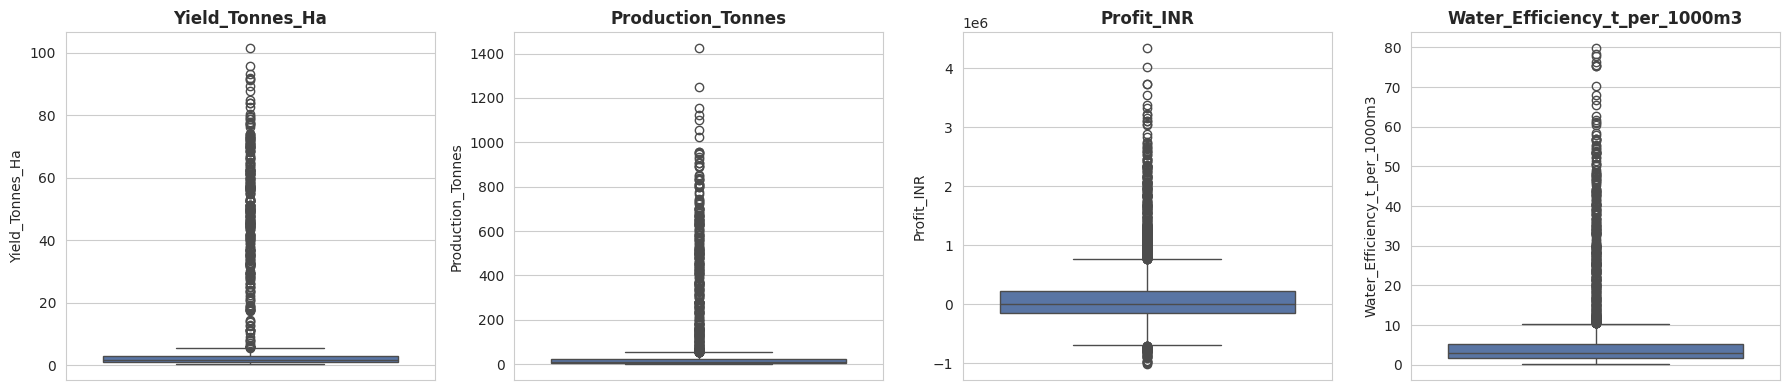

In [9]:
outlier_check_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR', 'Water_Efficiency_t_per_1000m3']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, outlier_check_cols):
    sns.boxplot(y=df[col], ax=ax, color='#4C72B0')
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [10]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

for col in outlier_check_cols:
    low, high = iqr_bounds(df[col])
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col}: bounds=({low:.2f}, {high:.2f}) -> {n_out} outliers ({n_out/len(df)*100:.1f}%)")


Yield_Tonnes_Ha: bounds=(-1.63, 5.52) -> 304 outliers (7.6%)
Production_Tonnes: bounds=(-23.98, 53.36) -> 333 outliers (8.3%)
Profit_INR: bounds=(-696111.00, 763567.00) -> 404 outliers (10.1%)
Water_Efficiency_t_per_1000m3: bounds=(-3.57, 10.38) -> 322 outliers (8.1%)


We **cap (winsorize)** rather than delete these outliers at the 1st/99th percentile — this reduces the influence of extreme/likely data-entry values on means and correlations while keeping every farm record for the categorical seasonal comparisons.

In [11]:
cap_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR', 'Revenue_INR', 'Total_Cost_INR', 'Water_Efficiency_t_per_1000m3']

for col in cap_cols:
    lower, upper = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower, upper)

df[cap_cols].describe().T[['min', 'mean', 'max']]


,min,mean,max
Yield_Tonnes_Ha,0.30000,5.180677,7.082010e+01
Production_Tonnes,0.49990,41.385839,7.015908e+02
Profit_INR,-741708.50000,107285.855350,2.341399e+06
Revenue_INR,21419.28000,632203.703850,3.171877e+06
Total_Cost_INR,42634.82000,525684.155650,1.126429e+06
Water_Efficiency_t_per_1000m3,0.31791,5.281995,5.001457e+01


### 3.4 Feature Engineering

In [12]:
df['Cost_per_Tonne'] = df['Total_Cost_INR'] / df['Production_Tonnes'].replace(0, np.nan)
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR'].replace(0, np.nan)) * 100
df['Season'] = pd.Categorical(df['Season'], categories=SEASON_ORDER, ordered=True)

df[['Cost_per_Tonne', 'Profit_Margin_pct']].describe().T


,count,mean,std,min,25%,50%,75%,max
Cost_per_Tonne,4000.0,55107.856757,53165.699056,568.357511,23032.641975,37966.401557,64398.792590,296805.128205
Profit_Margin_pct,4000.0,-43.152882,150.279419,-1461.851219,-60.192762,1.146236,32.885876,85.716925


<a id='4'></a>
## 4. Univariate Analysis — What Does the Dataset Look Like?

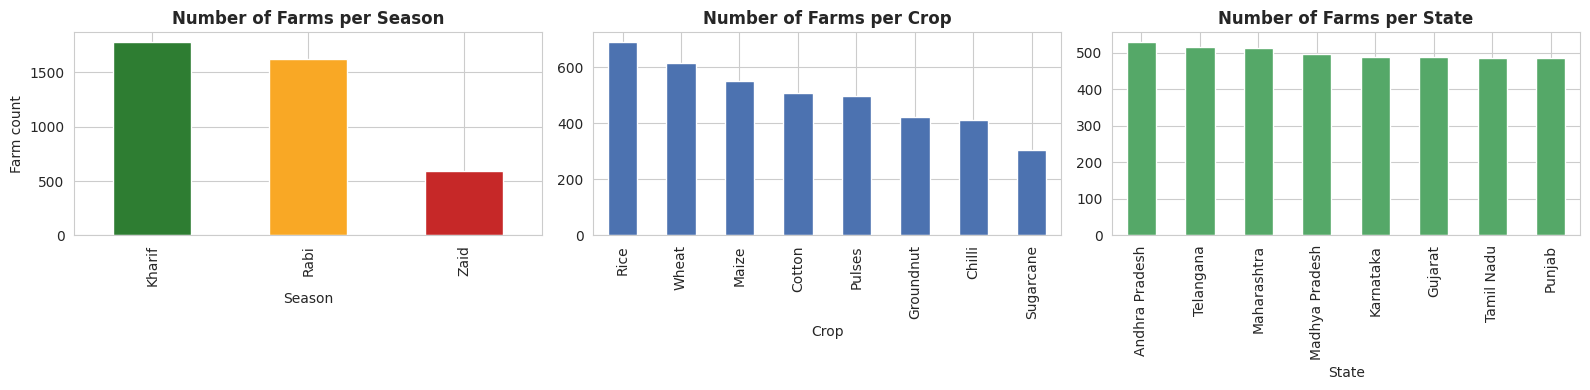

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df['Season'].value_counts().reindex(SEASON_ORDER).plot(kind='bar', ax=axes[0], color=[SEASON_PALETTE[s] for s in SEASON_ORDER])
axes[0].set_title('Number of Farms per Season'); axes[0].set_ylabel('Farm count')

df['Crop'].value_counts().plot(kind='bar', ax=axes[1], color='#4C72B0')
axes[1].set_title('Number of Farms per Crop')

df['State'].value_counts().plot(kind='bar', ax=axes[2], color='#55A868')
axes[2].set_title('Number of Farms per State')
plt.tight_layout()
plt.show()


In [14]:
pd.crosstab(df['Crop'], df['Season']).style.background_gradient(cmap='Greens')


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


This cross-tab shows **which crops are grown in which seasons** in the dataset — important context before comparing performance, since a crop that is only grown in one season will drive that season's averages.

<a id='5'></a>
## 5. Seasonal Comparison — Environmental Conditions

How do rainfall, temperature, humidity and sunlight differ across Kharif, Rabi and Zaid?

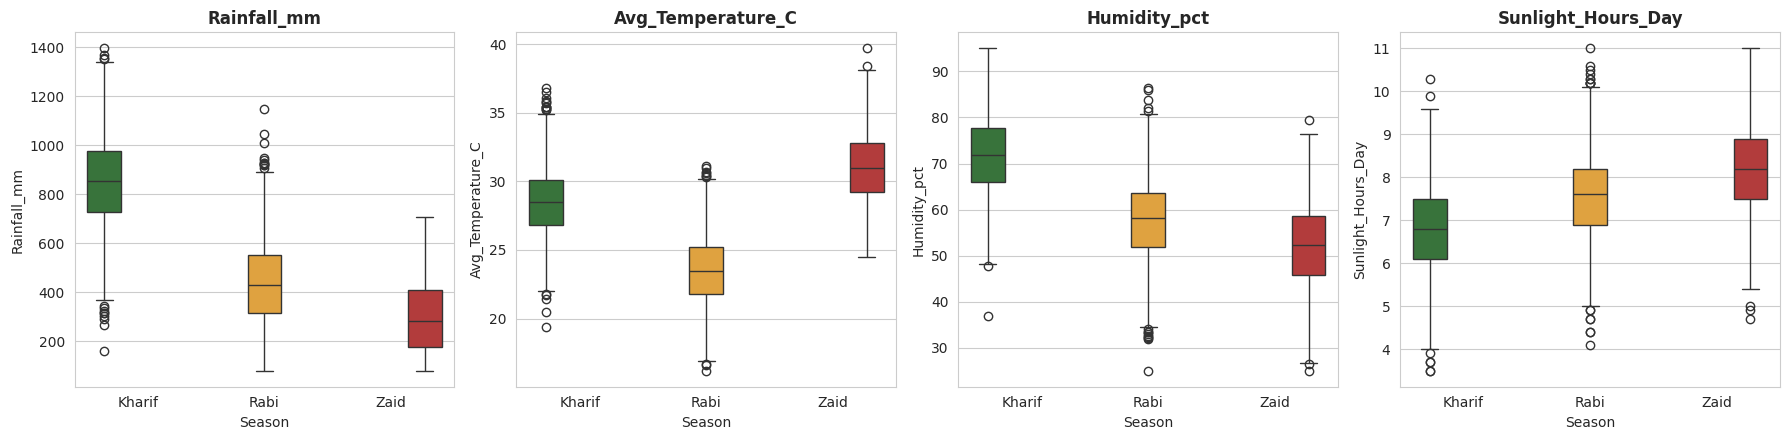

In [15]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day']

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col in zip(axes, env_cols):
    sns.boxplot(data=df, x='Season', y=col, hue='Season', order=SEASON_ORDER,
                palette=SEASON_PALETTE, legend=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [16]:
df.groupby('Season', observed=True)[env_cols].mean().round(2)


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day
Season,,,,
Kharif,852.10,28.45,71.81,6.79
Rabi,435.95,23.49,57.89,7.59
Zaid,299.16,31.04,52.01,8.18


<a id='6'></a>
## 6. Seasonal Comparison — Resource Usage

Comparing fertilizer, pesticide, water usage and irrigation choices across seasons.

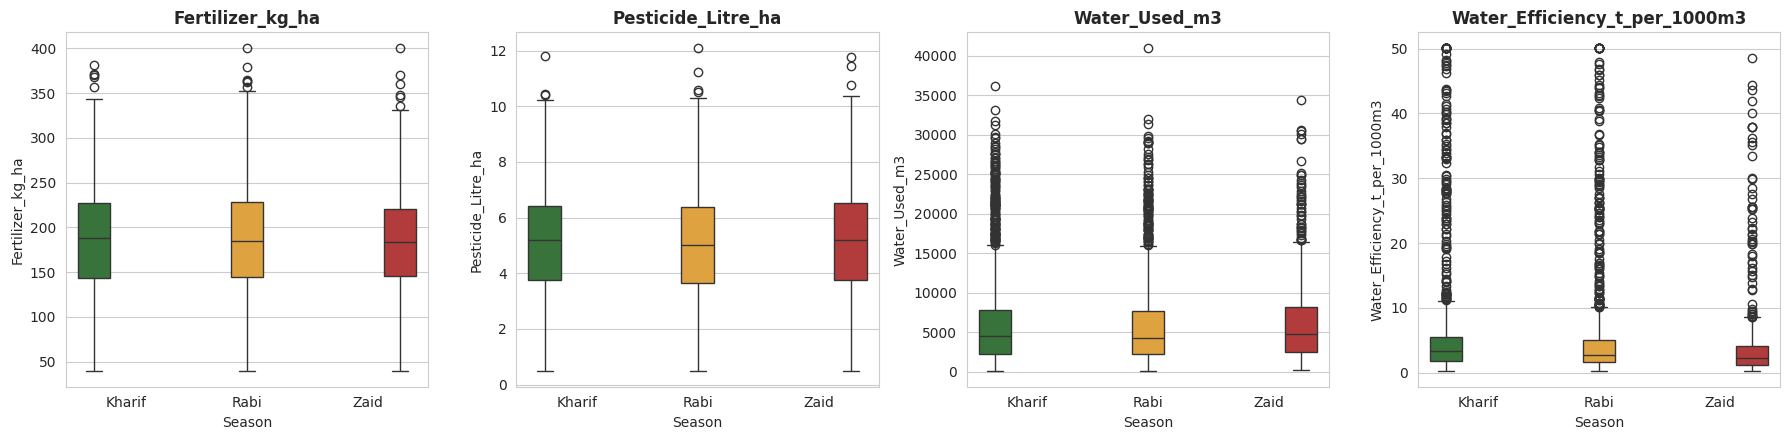

In [17]:
resource_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col in zip(axes, resource_cols):
    sns.boxplot(data=df, x='Season', y=col, hue='Season', order=SEASON_ORDER,
                palette=SEASON_PALETTE, legend=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


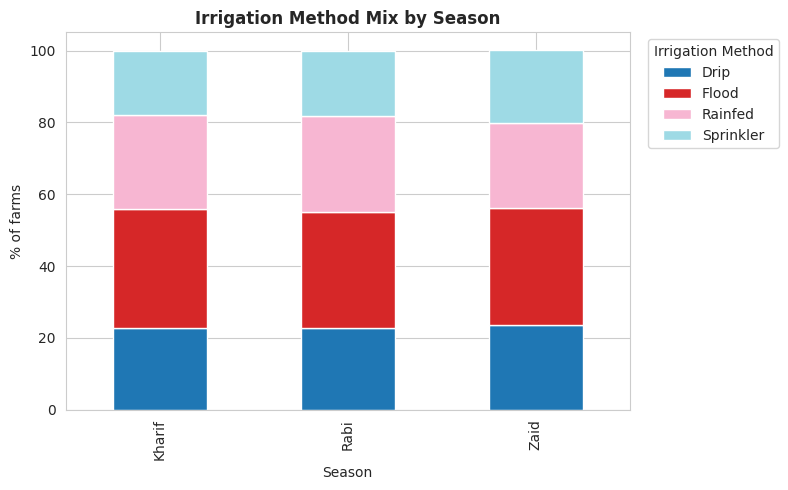

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


In [18]:
irrigation_season = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index') * 100
irrigation_season = irrigation_season.round(1)
irrigation_season.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='tab20')
plt.ylabel('% of farms')
plt.title('Irrigation Method Mix by Season')
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()
irrigation_season


<a id='7'></a>
## 7. Seasonal Comparison — Yield & Production

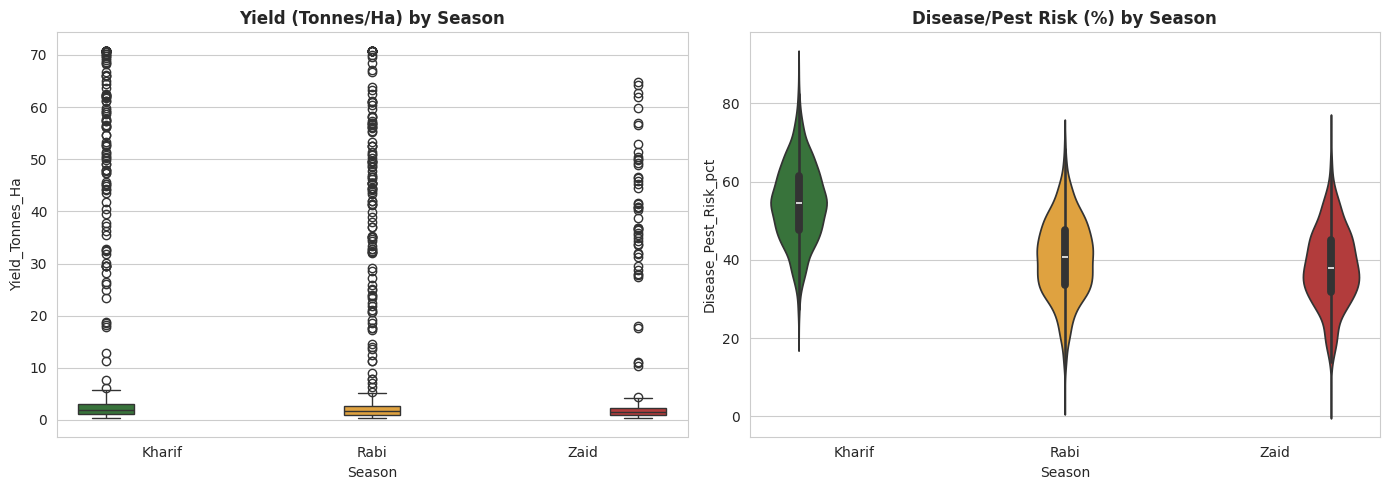

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', hue='Season', order=SEASON_ORDER,
            palette=SEASON_PALETTE, legend=False, ax=axes[0])
axes[0].set_title('Yield (Tonnes/Ha) by Season')

sns.violinplot(data=df, x='Season', y='Disease_Pest_Risk_pct', hue='Season', order=SEASON_ORDER,
               palette=SEASON_PALETTE, legend=False, ax=axes[1])
axes[1].set_title('Disease/Pest Risk (%) by Season')
plt.tight_layout()
plt.show()


In [20]:
df.groupby('Season', observed=True)[['Yield_Tonnes_Ha', 'Production_Tonnes', 'Disease_Pest_Risk_pct', 'Seed_Quality_Score']].agg(['mean', 'median', 'std']).round(2)


Yield_Tonnes_Ha               Production_Tonnes                 \
                  mean median    std              mean median     std   
Season                                                                  
Kharif            5.50   1.95  13.70             43.79  13.24  119.36   
Rabi              5.03   1.66  12.47             39.90  11.08  110.89   
Zaid              4.64   1.45  11.27             38.27   9.97  107.68   

       Disease_Pest_Risk_pct               Seed_Quality_Score              
                        mean median    std               mean median  std  
Season                                                                     
Kharif                 54.47   54.5  10.09               0.82   0.82  0.1  
Rabi                   40.48   40.6  10.10               0.83   0.84  0.1  
Zaid                   38.22   37.9   9.87               0.82   0.83  0.1

<a id='8'></a>
## 8. Seasonal Comparison — Economic Performance

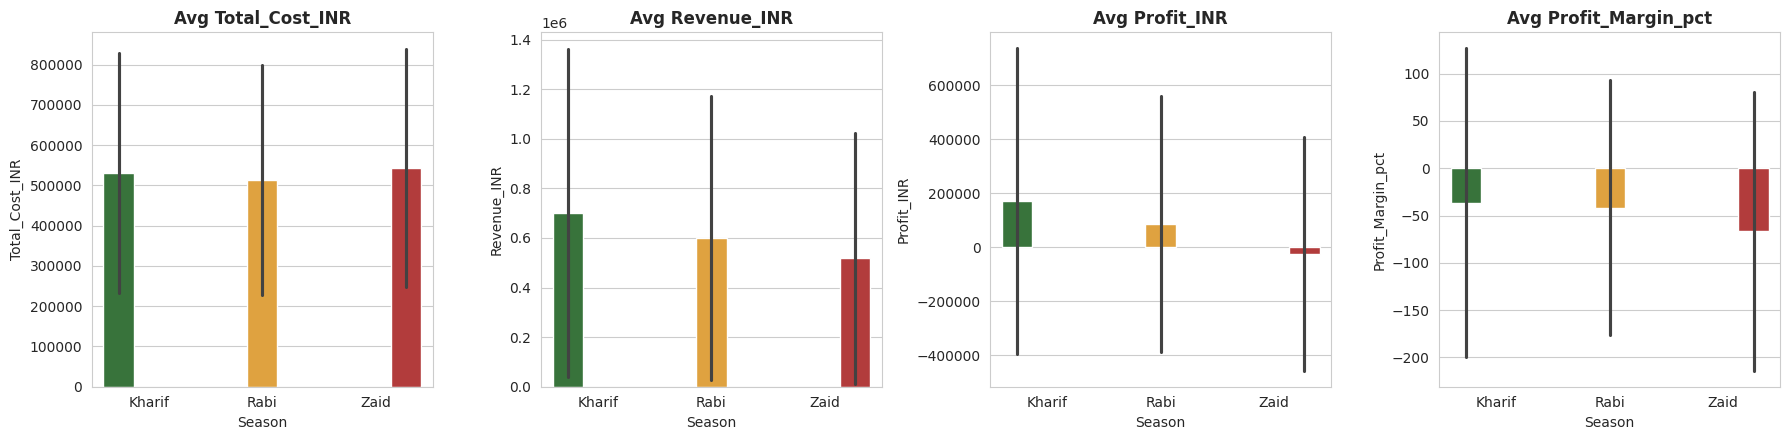

In [21]:
econ_cols = ['Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Profit_Margin_pct']

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col in zip(axes, econ_cols):
    sns.barplot(data=df, x='Season', y=col, hue='Season', order=SEASON_ORDER, palette=SEASON_PALETTE,
                legend=False, ax=ax, estimator=np.mean, errorbar='sd')
    ax.set_title(f'Avg {col}')
plt.tight_layout()
plt.show()


In [22]:
df.groupby('Season', observed=True)[econ_cols + ['Market_Price_INR_Tonne']].mean().round(2)


,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct,Market_Price_INR_Tonne
Season,,,,,
Kharif,531470.41,699997.19,170100.80,-36.71,44850.91
Rabi,513071.59,599512.48,86254.12,-41.54,44747.97
Zaid,542901.15,518708.77,-23234.61,-66.87,44212.03


<a id='9'></a>
## 9. Relationships Between Variables

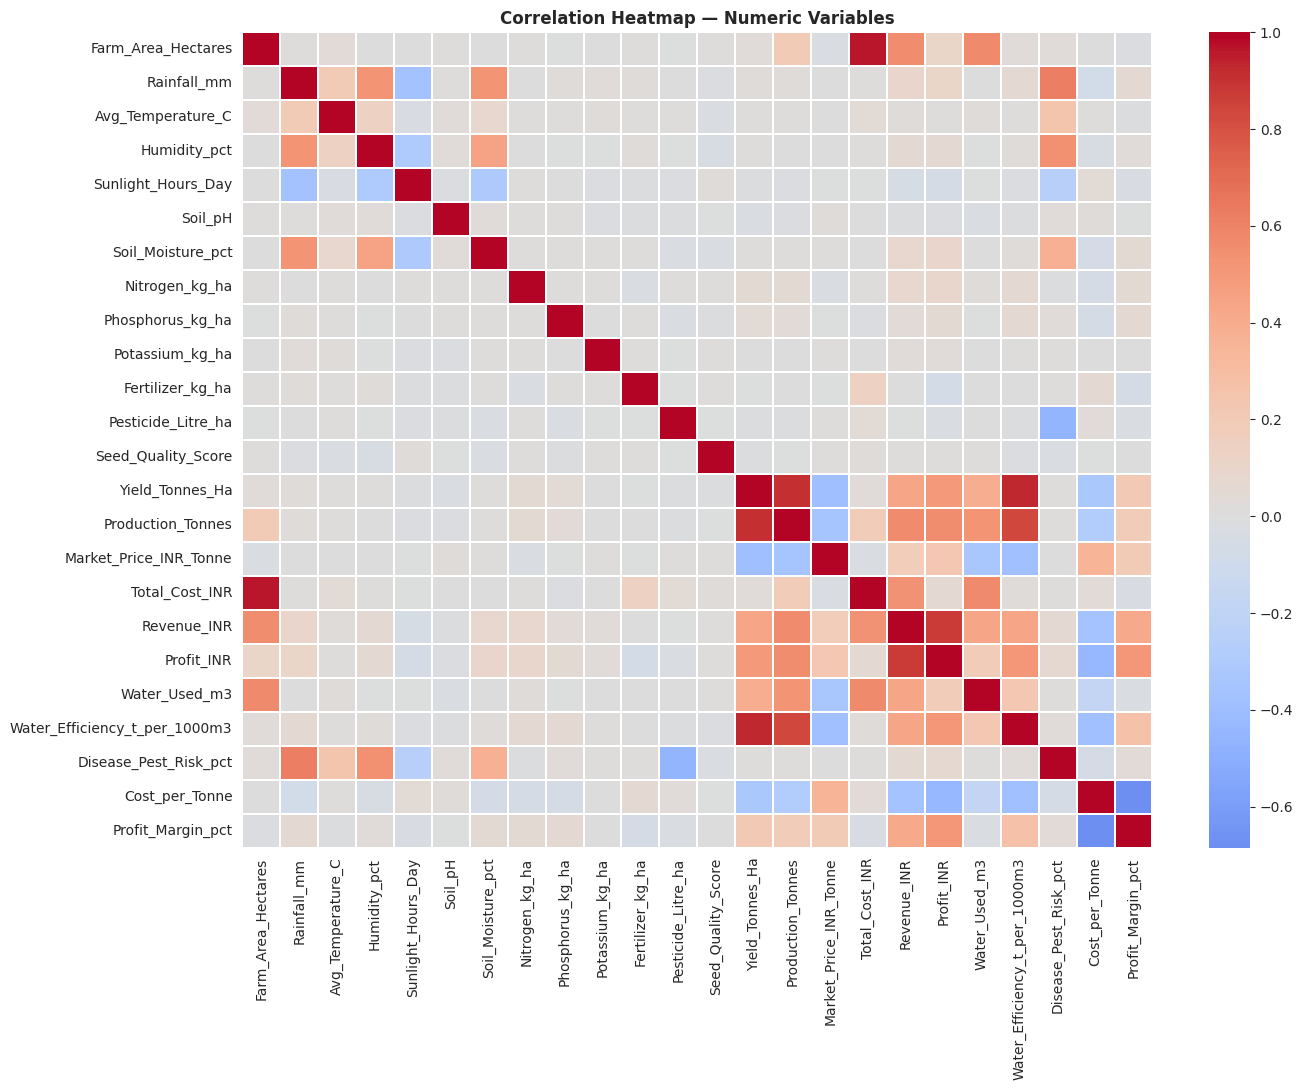

In [23]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Correlation Heatmap — Numeric Variables')
plt.tight_layout()
plt.show()


In [24]:
top_corr_with_yield = corr['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(key=abs, ascending=False)
print("Variables most correlated with Yield_Tonnes_Ha:\n")
print(top_corr_with_yield.head(10).round(3))

top_corr_with_profit = corr['Profit_INR'].drop('Profit_INR').sort_values(key=abs, ascending=False)
print("\nVariables most correlated with Profit_INR:\n")
print(top_corr_with_profit.head(10).round(3))


Variables most correlated with Yield_Tonnes_Ha:

Water_Efficiency_t_per_1000m3    0.930
Production_Tonnes                0.902
Profit_INR                       0.499
Revenue_INR                      0.437
Water_Used_m3                    0.393
Market_Price_INR_Tonne          -0.389
Cost_per_Tonne                  -0.319
Profit_Margin_pct                0.213
Nitrogen_kg_ha                   0.051
Phosphorus_kg_ha                 0.045
Name: Yield_Tonnes_Ha, dtype: float64

Variables most correlated with Profit_INR:

Revenue_INR                      0.878
Production_Tonnes                0.554
Profit_Margin_pct                0.507
Water_Efficiency_t_per_1000m3    0.507
Yield_Tonnes_Ha                  0.499
Cost_per_Tonne                  -0.439
Market_Price_INR_Tonne           0.226
Water_Used_m3                    0.190
Farm_Area_Hectares               0.111
Rainfall_mm                      0.106
Name: Profit_INR, dtype: float64


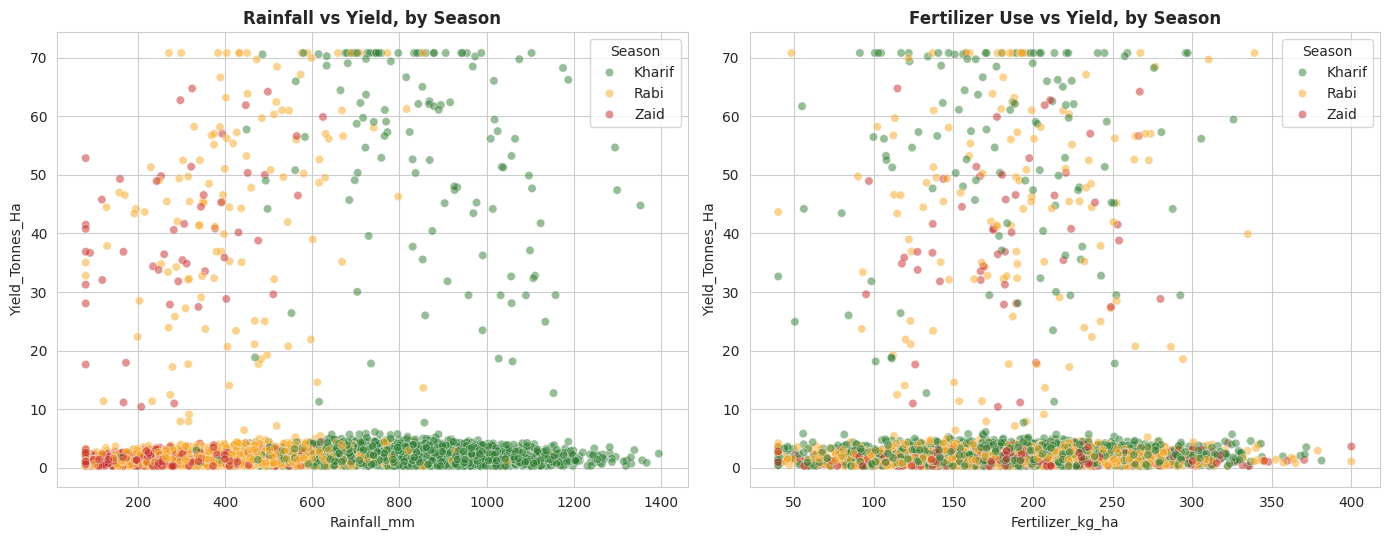

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', hue_order=SEASON_ORDER,
                 palette=SEASON_PALETTE, alpha=0.5, ax=axes[0])
axes[0].set_title('Rainfall vs Yield, by Season')

sns.scatterplot(data=df, x='Fertilizer_kg_ha', y='Yield_Tonnes_Ha', hue='Season', hue_order=SEASON_ORDER,
                 palette=SEASON_PALETTE, alpha=0.5, ax=axes[1])
axes[1].set_title('Fertilizer Use vs Yield, by Season')
plt.tight_layout()
plt.show()


<a id='10'></a>
## 10. Crop × Season & State × Season Analysis

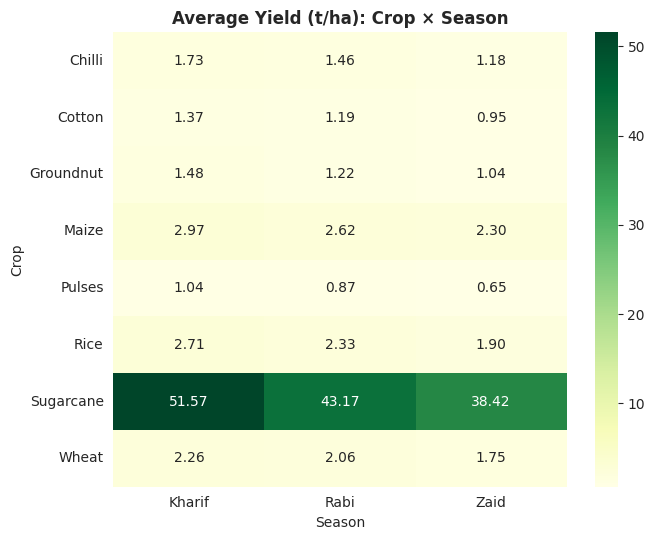

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.62,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,51.57,43.17,38.42
Wheat,2.26,2.06,1.75


In [26]:
crop_season_yield = df.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha',
                                    aggfunc='mean', observed=True)[SEASON_ORDER]
plt.figure(figsize=(7, 5.5))
sns.heatmap(crop_season_yield, annot=True, fmt='.2f', cmap='YlGn')
plt.title('Average Yield (t/ha): Crop × Season')
plt.tight_layout()
plt.show()
crop_season_yield.round(2)


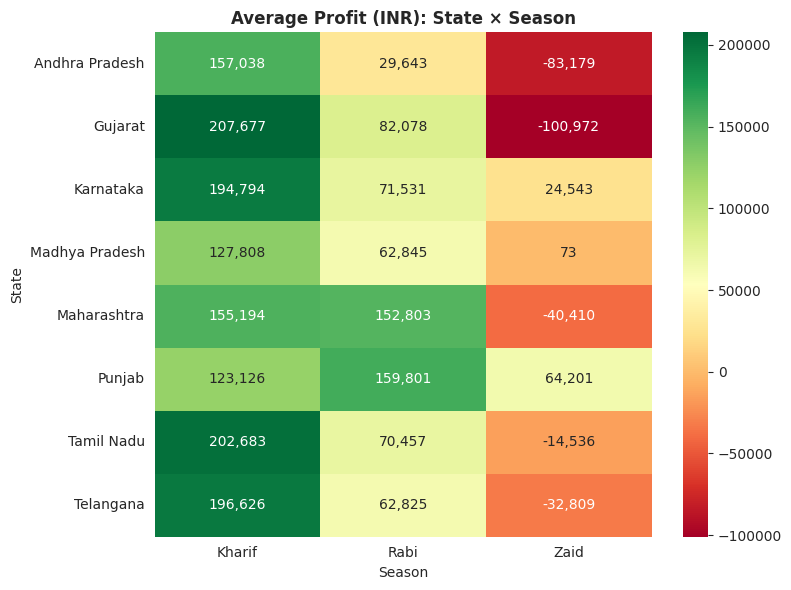

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,157038.0,29643.0,-83179.0
Gujarat,207677.0,82078.0,-100972.0
Karnataka,194794.0,71531.0,24543.0
Madhya Pradesh,127808.0,62845.0,73.0
Maharashtra,155194.0,152803.0,-40410.0
Punjab,123126.0,159801.0,64201.0
Tamil Nadu,202683.0,70457.0,-14536.0
Telangana,196626.0,62825.0,-32809.0


In [27]:
state_season_profit = df.pivot_table(index='State', columns='Season', values='Profit_INR',
                                      aggfunc='mean', observed=True)[SEASON_ORDER]
plt.figure(figsize=(8, 6))
sns.heatmap(state_season_profit, annot=True, fmt=',.0f', cmap='RdYlGn')
plt.title('Average Profit (INR): State × Season')
plt.tight_layout()
plt.show()
state_season_profit.round(0)


<a id='11'></a>
## 11. Statistical Testing

We test whether the differences in **Yield** and **Profit** observed across seasons are statistically significant, using a one-way ANOVA (comparing means of 3+ independent groups).

- **H0 (null hypothesis):** The mean is equal across all three seasons.
- **H1 (alternative hypothesis):** At least one season's mean differs.

In [28]:
for metric in ['Yield_Tonnes_Ha', 'Profit_INR', 'Total_Cost_INR']:
    groups = [df.loc[df['Season'] == s, metric].dropna() for s in SEASON_ORDER]
    f_stat, p_val = stats.f_oneway(*groups)
    verdict = "significant difference (reject H0)" if p_val < 0.05 else "no significant difference (fail to reject H0)"
    print(f"{metric:20s} -> F={f_stat:8.2f}, p={p_val:.4g}  =>  {verdict}")


Yield_Tonnes_Ha      -> F=    1.18, p=0.3079  =>  no significant difference (fail to reject H0)
Profit_INR           -> F=   33.98, p=2.331e-15  =>  significant difference (reject H0)
Total_Cost_INR       -> F=    2.89, p=0.05587  =>  no significant difference (fail to reject H0)


<a id='12'></a>
## 12. Key Insights

1. **Yield:** Kharif shows the highest average yield (5.50 t/ha) vs Zaid (4.64 t/ha) — but this is not supported by the ANOVA result (p = 0.31),   meaning the difference isn't statistically significant and could be due to normal variation rather than season itself.
2. **Environmental drivers:** Rainfall/temperature in Kharif (852 mm rainfall, 28.5°C) create the most favorable conditions for Sugarcane, which posts by far the highest yield of any crop in that season (51.57 t/ha, vs 38.42 t/ha in Zaid).
3. **Resource usage:** Water use is highest in Zaid (6,420 m³ avg, vs 6,102 in Kharif and 5,847 in Rabi), but this does not translate to higher yield — Zaid actually has the lowest water efficiency (4.41 t/1000m³ vs 5.89 in Kharif) and the lowest yield of the three seasons, confirming water is being used least productively in Zaid.
4. **Economics:** Kharif farms are the most profitable on average (₹170,101 profit), driven by higher revenue (₹699,997) rather than lower cost — costs are actually similar or even slightly lower than Zaid's (₹531,470 vs ₹542,901) across seasons, so revenue is the deciding factor, not cost control.
5. **Risk:** Disease/pest risk is elevated in Kharif (54.5% vs ~40% in Rabi and 38% in Zaid), likely due to its high rainfall/humidity — yet Kharif still posts the best yield and profit, suggesting the risk hasn't yet translated into lower output at these levels.
6. **Regional patterns:** Gujarat shows the strongest state-level swing tied to season — it's the top-profit state in Kharif (₹207,677) but drops to one of the worst performers in Zaid (-₹100,972), making it the most season-sensitive state in the dataset rather than a consistently top performer.
7. **Unexpected pattern:** Fertilizer and nutrient inputs (Nitrogen, Phosphorus) show almost no correlation with yield (r ≈ 0.05 and 0.045), despite fertilizer being a major cost input — while water efficiency correlates very strongly with yield (r = 0.93). This suggests farms may be over-relying on fertilizer as a yield lever when water management is the far more impactful factor.


<a id='13'></a>
## 13. Conclusions & Recommendations

**Conclusions** 

Seasonal agricultural performance in this dataset is shaped less by yield differences (which are not statistically significant across seasons) and more by economic outcomes, which differ sharply and significantly. Kharif is the most environmentally favorable and most profitable season, aided by high rainfall, despite carrying the highest disease/pest risk. Zaid is the weakest season economically — low rainfall and high heat suppress revenue enough to push average profit negative, even though costs remain similar to other seasons. Water efficiency, not nutrient input, is the strongest driver of yield, and revenue growth (not cost-cutting) is the strongest driver of profit.

**Recommendations for stakeholders**
1. **For farmers:** e.g., adjust fertilizer/irrigation strategy for the lowest-yield season.
2. **For policymakers:** e.g., prioritize crop insurance or price support in the riskiest season.
3. **For agri-businesses:** e.g., time input supply (seed, fertilizer) ahead of the highest-demand season.
4. **For further investigation:** e.g., district-level micro-climate data, multi-year trends instead of a single snapshot.

